In [1]:
from time import time
import numpy as np
from collections import Counter
import random, json, re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.manifold import TSNE


random.seed(int(time()))
np.random.seed(int(time()))


In [2]:
def load_lines(path):
    with open(path, 'r', encoding='utf-8') as f:
      text = f.read()
      articles = re.split(r"\[\d+\]", text)
      return articles

raw_docs     = load_lines('raw.txt')[1:]
cleaned_docs = load_lines('cleaned.txt')[1:]

with open('metadata.json', 'r', encoding='utf-8') as f:
    metadata = json.load(f)

print(f'Raw docs    : {len(raw_docs)}')
print(f'Cleaned docs: {len(cleaned_docs)}')
print(f'Metadata    : {len(metadata)} entries')

Raw docs    : 300
Cleaned docs: 300
Metadata    : 300 entries


In [6]:
politics_kw = [
    "حکومت", "وزیر", "پارلیمان", "الیکشن", "سیاسی", "وزیراعظم", "اسمبلی", "عدالت", "احتجاج"
]

sports_kw = [
    "کرکٹ", "میچ", "ٹیم", "کھلاڑی", "ورلڈ کپ", "وکٹ", "اسکور", "کھیل", "سیریز"
]

economy_kw = [
    "معیشت", "مہنگائی", "بینک", "تجارت", "بجٹ", "ڈالر", "سرمایہ", "ٹیکس", "کرنسی"
]

international_kw = [
    "امریکہ", "ایران", "چین", "بھارت", "اقوام متحدہ", "معاہدہ", "جنگ", "سفارت", "روس", "یوکرین"
]

health_kw = [
    "ہسپتال", "بیماری", "ویکسین", "صحت", "تعلیم", "سیلاب", "ڈاکٹر", "علاج", "آپریشن"
]

actors_kw = [
    "اداکار", "اداکارہ", "فلم", "ڈرامہ", "بالی ووڈ", "شوبز", "گلوکار", "ہیرو", "ہیروئن", "سینما"
]

science_kw = [
    "سائنس", "ٹیکنالوجی", "مصنوعی ذہانت", "AI", "روبوٹ", "خلاء", "سیارہ", "ناسا", "تحقیق", "انٹرنیٹ"
]


# 🔷 Step 3: Classification Function
def classify(title):
    scores = {
        "Politics": 0,
        "Sports": 0,
        "Economy": 0,
        "International": 0,
        "Health & Society": 0,
        "Actors & Entertainment": 0,
        "Science & Technology": 0
    }

    for word in politics_kw:
        if word in title:
            scores["Politics"] += 1

    for word in sports_kw:
        if word in title:
            scores["Sports"] += 1

    for word in economy_kw:
        if word in title:
            scores["Economy"] += 1

    for word in international_kw:
        if word in title:
            scores["International"] += 1

    for word in health_kw:
        if word in title:
            scores["Health & Society"] += 1

    for word in actors_kw:
        if word in title:
            scores["Actors & Entertainment"] += 1

    for word in science_kw:
        if word in title:
            scores["Science & Technology"] += 1

    # Handle no-match case
    if max(scores.values()) == 0:
        return "Other"

    return max(scores, key=scores.get)

# 🔷 Step 4: Apply Classification
results = {}

for key, value in metadata.items():
    title = value["title"]
    category = classify(title)
    
    results[key] = {
        "title": title,
        "category": category
    }

# 🔷 Step 5: Save Output
with open("classified_metadata.json", "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=4)

# 🔷 Step 6: Print Sample Output
print("Sample Results:\n")
for i, (k, v) in enumerate(results.items()):
    print(f"{k}: {v}")
    if i == 7:
        break

print("\n✅ Classification complete with extended categories.")
# coverage analysis
categories = [v["category"] for v in results.values()]
category_counts = Counter(categories)    

print("\nClassification complete. Saved as 'classified_metadata.json'")
print("Coverage Analysis:")
for category, count in category_counts.items():
    print(f"  {category}: {count}")

Sample Results:

1: {'title': 'ملاکنڈ ڈویژن کا انتظام فوج سے لے کر صوبائی انتظامیہ کو دینے کے فیصلے کا خیبر پختونخوا کی سکیورٹی صورتحال پر کیا اثر پڑے گا؟', 'category': 'Other'}
2: {'title': 'نیٹ میٹرنگ کے بجائے ’نیٹ بلنگ‘: نئے نظام سے نئے اور پرانے سولر صارفین کیسے متاثر ہوں گے؟', 'category': 'Other'}
3: {'title': '’صوبے کا وزیرِ اعلیٰ ہڑتال میں شرکت کرتا کیا اچھا لگے گا‘: آٹھ فروری کو پی ٹی آئی اور اپوزیشن جماعتوں کا احتجاج کتنا کامیاب رہا؟', 'category': 'Politics'}
4: {'title': 'حیات شیرپاؤ: ٹیپ ریکارڈر میں چھپا بم اور وہ ہائی پروفائل قتل جس کے ملزم ’افغانستان فرار ہو گئے‘', 'category': 'Other'}
5: {'title': 'پاکستان میں فیشن ڈیزائنر کیسے بنا جا سکتا ہے اور اس شعبے میں کمائی کتنی ہے؟', 'category': 'Other'}
6: {'title': '’نال کاٹنے کے اوزار نہیں تھے اور بچی رو بھی نہیں رہی تھی‘: درد سے تڑپتی خاتون اور پاکستانی ٹرین میں ڈیلیوری کی کہانی', 'category': 'Other'}
7: {'title': 'بسنت کے تہوار کی 19 سال بعد پاکستان میں واپسی، بی بی سی نے لاہور میں کیا دیکھا؟', 'category': 'Other'}
8: {'title

In [ ]:
all_tokens = [tok for doc in cleaned_docs for tok in doc.split()]
token_freq = Counter(all_tokens)
VOCAB_SIZE  = 10000

vocab_tokens = [w for w, _ in token_freq.most_common(VOCAB_SIZE - 1)]+['<UNK>']
word2idx     = {w: i for i, w in enumerate(vocab_tokens)}
idx2word     = {i: w for w, i in word2idx.items()}
V = len(vocab_tokens)
print(f'Vocabulary size: {V}')

with open('embeddings/word2idx.json', 'w', encoding='utf-8') as f:
    json.dump(word2idx, f, ensure_ascii=False)

N = len(cleaned_docs)
tf_matrix = np.zeros((N, V), dtype=np.float32)

for d_idx, doc in enumerate(cleaned_docs):
    tokens = doc.split()
    total  = len(tokens) if tokens else 1
    for tok in tokens:
        w_idx = word2idx.get(tok, word2idx['<UNK>'])
        tf_matrix[d_idx, w_idx] += 1
    tf_matrix[d_idx] /= total   

df = (tf_matrix > 0).sum(axis=0).astype(np.float32)    
idf = np.log(N / (1 + df))                             
tfidf_matrix = tf_matrix * idf                         

np.save('embeddings/tfidf_matrix.npy', tfidf_matrix)
print('TF-IDF matrix saved:', tfidf_matrix.shape)

Vocabulary size: 10001
TF-IDF matrix saved: (300, 10001)


In [10]:
print('Top-10 discriminative words per Article (TF-IDF):\n')
for i in range(len(cleaned_docs)):
    scores = tfidf_matrix[i]
    top10_idx = np.argsort(scores)[-10:][::-1]
    top10_words = [vocab_tokens[i] for i in top10_idx]
    print(f'  {i+1}: {top10_words}')


Top-10 discriminative words per Article (TF-IDF):

  1: ['ملاکنڈ', 'صوبایی', 'شدت', 'علاقہ', 'ڈویژن', 'اجلاس', 'سول', 'پولیس', 'فوج', 'خیبر']
  2: ['بجلی', 'سولر', 'بلنگ', 'نیٹ', 'میٹرنگ', 'گرڈ', 'صارفین', 'نیپرا', 'نظام', 'کھپت']
  3: ['ہڑتال', 'احتجاج', 'کارکن', 'بند', 'کوہاٹ', 'کویٹہ', 'دکان', 'پشاور', 'شٹر', 'پہیہ']
  4: ['شیرپاو', 'نیپ', 'بھٹو', 'بم', 'خان', 'انور', 'امجد', 'حیات', 'پشاور', 'خٹک']
  5: ['فیشن', 'ڈیزاینر', 'افضل', 'ڈیزایننگ', 'ڈیزاین', 'روپے', 'درزی', 'ایمن', 'کپڑے', 'کپڑ']
  6: ['ڈیلیوری', 'ٹرین', 'اسامہ', 'عبدالحلیم', 'خاتون', 'بوگی', 'بچی', 'امین', 'زچگی', 'ڈاکٹر']
  7: ['پتنگ', 'ڈور', 'تہوار', 'بسنت', 'آسم', 'صلاح', 'چھت', 'یوسف', 'الدین', 'کاشف']
  8: ['نوشکی', 'رفیق', 'بلوچست', 'سندھ', 'کویٹہ', 'احمد', 'گھوٹکی', 'دکان', 'ٹھیکی', 'مزدوری']
  9: ['ملزم', 'مقتول', 'اسحاق', 'پولیس', 'چکوال', 'اعضا', 'قتل', 'اندھے', 'بازو', 'نشان']
  10: ['بسنت', 'پتنگ', 'ڈور', 'تہوار', 'لاہور', 'پنجاب', 'منایی', 'کاریگر', 'پیز', 'منایا']
  11: ['عون', 'عباس', 'بہادر', 'نماز', 'سی

In [23]:
WINDOW = 5

PPMI_VOCAB = 5000
cooc = np.zeros((PPMI_VOCAB, PPMI_VOCAB), dtype=np.float32)

for doc in cleaned_docs:
    tokens = doc.split()
    ids = [word2idx.get(t, 10000) for t in tokens]
    ids = [i for i in ids if i < PPMI_VOCAB]
    for i, w in enumerate(ids):
        lo = max(0, i - WINDOW)
        hi = min(len(ids), i + WINDOW + 1)
        for j in range(lo, hi):
            if i != j:
                cooc[w, ids[j]] += 1

total      = cooc.sum() + 1e-10
row_sums   = cooc.sum(axis=1, keepdims=True) + 1e-10
col_sums   = cooc.sum(axis=0, keepdims=True) + 1e-10
expected   = (row_sums @ col_sums) / total
with np.errstate(divide='ignore', invalid='ignore'):
    pmi = np.log2((cooc + 1e-10) / (expected + 1e-10))
ppmi_matrix = np.maximum(0, pmi)

np.save('embeddings/ppmi_matrix.npy', ppmi_matrix)
print('PPMI matrix saved:', ppmi_matrix.shape)

PPMI matrix saved: (5000, 5000)


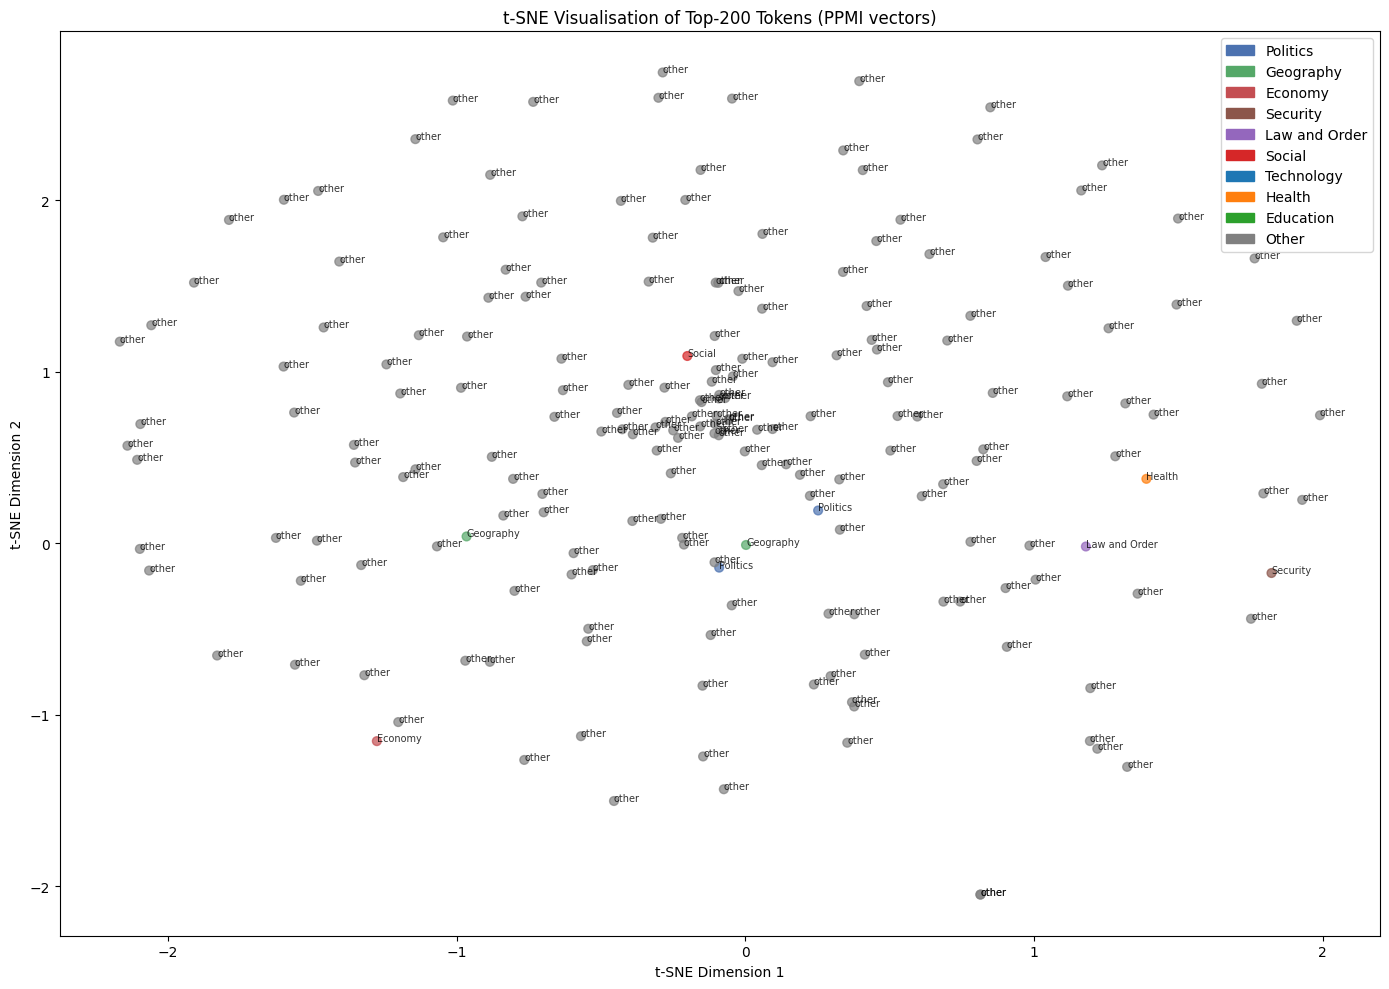

In [24]:
TOP_N = 200
top_indices = [word2idx[w] for w, _ in token_freq.most_common(TOP_N) if word2idx[w] < PPMI_VOCAB]
top_indices = top_indices[:TOP_N]
top_words   = [vocab_tokens[i] for i in top_indices]
top_vecs    = ppmi_matrix[top_indices]

word_to_cat = {}
politics_kw = [
'حکومت','وزیر','پارلیمان','فوج','سیاسی','وفاق','صوبہ','قانون',
'وزیراعظم','وزیراعلی','اپوزیشن','حکمر','انتخاب','ووٹ','ریلی','احتجاج',
'پارٹی','قیادت','رہنما','کمیٹی','اعلامیہ','اجلاس','مشیر','اتحاد',
'مینڈیٹ','حلف','گورنر','اسمبلی','پالیسی','فیصلہ','سیاسی جماعت'
]
geo_kw = [
'پاکستان','ملاکنڈ','سوات','پشاور','خیبر','افغانستان','دیر','چترال',
'بلوچستان','کوہاٹ','کراچی','اسلام آباد','راولپنڈی','لاہور',
'باجوڑ','شانگلہ','کرم','شمالی علاقہ','سرحد','صوبہ','شہر',
'یونیورسٹی','سٹیشن','علاقہ','ضلع'
]
economy_kw = [
'بجلی','نیٹ','سولر','ٹیرف','قیمت','بلنگ','میٹرنگ','نیپرا',
'گرڈ','یونٹ','لوڈ','توانائی','پاور','کمپنی','معاہدہ','قواعد',
'کھپت','پیداوار','سسٹم','بیٹری','سرمایہ','معاشی','اخراجات',
'ریٹ','خریداری','فروخت','نرخ'
]
security_kw = [
'شدت پسند','دہشت گردی','آپریشن','انٹیلیجنس','سی ٹی ڈی',
'فوجی','حملہ','ڈراون','اسلحہ','کارروائی','مزاحمت',
'چوکی','ناک','سیکیورٹی','خطرہ','دھماکہ','جنگ','محاذ'
]
law_order_kw = [
'پولیس','گرفتار','مقدمہ','عدالت','قانون نافذ','اہلکار',
'تحقیقات','ملزم','کیس','کارروائی','حراست','جرم',
'انسداد','عدالتی','ٹریبونل','شکایت'
]
social_kw = [
'عوام','لوگ','مقامی','شہری','طلبہ','کارکن','خاندان',
'رابطہ','مطالبہ','تشویش','ردعمل','ثقافت','زندگی',
'مسائل','رہائش','سماجی','ریلی','برادری'
]
tech_kw = [
'سسٹم','ٹیکنالوجی','ڈرون','ڈیٹا','نیٹ ورک','مشین',
'سسٹمز','ڈیجیٹل','آن لائن','سافٹ ویئر','پروسیس',
'انفارمیشن','ٹیکنیکل','آلات'
]
health_kw = [
'ڈاکٹر','ہسپتال','ایمبولینس','علاج','مریض','طبی',
'ڈیلیوری','زچگی','خون','درد','ادویات','نرس',
'ریسکیو','طبی امداد'
]
education_kw = [
'یونیورسٹی','تعلیم','طلبہ','ڈگری','کورس','تحقیق',
'اساتذہ','تعلیمی','ادارہ','سیکھنا','لیکچر','امتحان'
]
for w in politics_kw: word_to_cat[w] = 'Politics'
for w in geo_kw:      word_to_cat[w] = 'Geography'
for w in economy_kw:  word_to_cat[w] = 'Economy'
for w in security_kw: word_to_cat[w] = 'Security'
for w in law_order_kw: word_to_cat[w] = 'Law and Order'
for w in social_kw: word_to_cat[w] = 'Social'
for w in tech_kw: word_to_cat[w] = 'Technology'
for w in health_kw: word_to_cat[w] = 'Health'
for w in education_kw: word_to_cat[w] = 'Education'

cat_colors = {'Politics':'#4C72B0','Geography':'#55A868','Economy':'#C44E52','Security':'#8C564B','Law and Order':'#9467BD','Social':'#D62728','Technology':'#1F77B4','Health':'#FF7F0E','Education':'#2CA02C','Other':'#808080'}
colors = [cat_colors.get(word_to_cat.get(w,'Other'),'#808080') for w in top_words]

tsne = TSNE(n_components=2, perplexity=30)
coords = tsne.fit_transform(top_vecs)

fig, ax = plt.subplots(figsize=(14, 10))
ax.scatter(coords[:,0], coords[:,1], c=colors, s=40, alpha=0.7)
for i, w in enumerate(top_words):
    ax.annotate(word_to_cat.get(w, 'other'), (coords[i,0], coords[i,1]), fontsize=7, alpha=0.8)

handles = [mpatches.Patch(color=v, label=k) for k,v in cat_colors.items()]
ax.legend(handles=handles, loc='upper right')
ax.set_title('t-SNE Visualisation of Top-200 Tokens (PPMI vectors)')
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
plt.tight_layout()
plt.show()

In [25]:
def cosine_sim_matrix(mat):
    norms = np.linalg.norm(mat, axis=1, keepdims=True) + 1e-10
    return (mat / norms) @ (mat / norms).T

sim = cosine_sim_matrix(ppmi_matrix[:PPMI_VOCAB])

query_words_ppmi = ['پاکستان','فوج','سوات','پولیس','بجلی','حکومت','علاقہ','امن','سولر','شدت']

print('Top-5 nearest neighbours (PPMI cosine similarity):\n')
for qw in query_words_ppmi:
    idx = word2idx.get(qw)
    if idx is None or idx >= PPMI_VOCAB:
        print(f'  {qw}: not in PPMI vocab'); continue
    scores = sim[idx].copy()
    scores[idx] = -1
    top5 = np.argsort(scores)[-5:][::-1]
    print(f'  {qw}: {[vocab_tokens[i] for i in top5]}')

Top-5 nearest neighbours (PPMI cosine similarity):

  پاکستان: ['انڈیا', 'ٹیم', 'کے', 'کرکٹ', 'میں']
  فوج: ['فوجی', 'ایرانی', 'کے', 'افواج', 'افسر']
  سوات: ['اپر', 'فالٹ', 'آدھی', 'پختونخوا', 'مہلک']
  پولیس: ['افسر', 'نے', 'درج', 'بتایا', 'سٹیشن']
  بجلی: ['سولر', 'گرڈ', 'کھپت', 'میٹرنگ', 'بلنگ']
  حکومت: ['کے', 'اور', 'کی', 'کو', 'پاکستان']
  علاقہ: ['کے', 'میں', 'شہر', 'اور', 'واقع']
  امن: ['غزہ', 'کمیٹی', 'امان', 'قایم', 'فلسطینی']
  سولر: ['میٹرنگ', 'بجلی', 'بلنگ', 'گرڈ', 'نان']
  شدت: ['پسند', 'پسندی', 'تنظیم', 'عسکریت', 'بلوچ']
